# Autoregressive joint smoothing with BayesFlow

This smoke example constructs and builds an `AutoregressiveApproximator` for
$p(\theta_{1:T} \mid x_{1:T}, c) = \prod_t p(\theta_t \mid x_{1:T}, c, \theta_{<t})$, then draws complete trajectories from an untrained coupling flow. In a real Superstats workflow, replace the synthetic arrays with adapted simulator output and train before sampling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bayesflow as bf

import superstats as sup

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


In [2]:
joint_prior = sup.JointPrior(
    v=sup.transition.RandomWalk(), 
    a=sup.transition.RandomWalk(bounds=(0.1, 4.0)),
    tau=0.3,
    bias=0.5
)

model = sup.Model(
    prior=joint_prior, 
    simulator=sup.simulation.sample_ddm, 
    missing=None,
    contamination=None
)

In [3]:
adapter = (bf.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series(["time_steps", "response_time", "choice"])
    .concatenate(["time_steps", "response_time", "choice"], into="summary_variables")
    .concatenate(["v", "a"], into="inference_variables")
)

In [4]:
train_data = model.sample(5000, num_steps=50)

train_dataset = bf.OfflineDataset(
    data=train_data,
    batch_size=32,
    adapter=adapter
)

In [10]:
encoder = bf.networks.TimeSeriesTransformer(
    summary_dim=16,
    embed_dims=(32, 32),
    num_heads=(2, 2),
    return_sequences=True,
)

decoder = bf.networks.TransformerDecoder(
    summary_dim=16,
    embed_dim=16,
    num_layers=2,
    num_heads=2,
)

inference_network = bf.networks.CouplingFlow(depth=4)

approximator = bf.AutoregressiveApproximator(
    inference_network=inference_network,
    encoder_network=encoder,
    decoder_network=decoder,
    adapter=adapter,
    standardize=None
)

approximator.compile(optimizer="adamw")

In [11]:
h = approximator.fit(
    dataset=train_dataset,
    epochs=25
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 154ms/step - loss: 0.5790
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - loss: -0.7011
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - loss: -1.7277
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - loss: -2.3887
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - loss: -2.5897
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 169ms/step - loss: -2.8043
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - loss: -2.8522
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - loss: -2.9850
Epoch 9/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - loss: -2.9188
Epoch 10/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - loss: -3.1152
Epoch 11/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - loss: -3.1403
Epoch 12/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - loss: -3.1756
Epoch 13/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - loss: -3.2039
Epoch 14/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - loss: -3.2260
Ep

In [12]:
test_data = model.sample(10, num_steps=50)

samples = approximator.sample(conditions=test_data, num_samples=100)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

c:\Users\radevs\AppData\Local\anaconda3\envs\bf\Lib\site-packages\keras\src\ops\nn.py:959: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1000, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


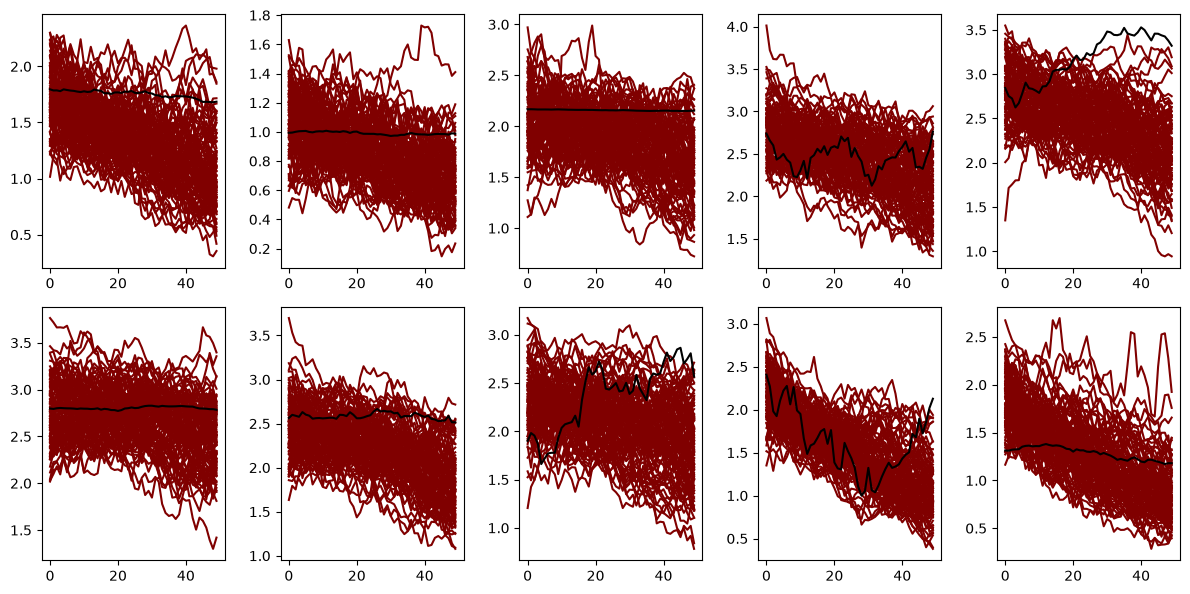

In [15]:
f, axarr = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axarr.flat):
    ax.plot(samples["a"][i].squeeze().T, color="maroon")
    ax.plot(test_data["a"][i].squeeze(), color="black")

f.tight_layout()